Install

In [3]:
!pip install -q transformers peft accelerate bitsandbytes datasets trl lxml cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.3 MB/s eta 0:00:00


Extract the data zip file and read

In [4]:
import os
import re
import zipfile
import random
import numpy as np
import pandas as pd
import torch

from lxml import etree
import cairosvg

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer

In [5]:
zip_path = "/content/dl-spring-2026-svg-generation.zip"
extract_dir = "/content/svg_competition_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print(os.listdir(extract_dir))

train_df = pd.read_csv("/content/svg_competition_data/train.csv")
test_df = pd.read_csv("/content/svg_competition_data/test.csv")
sample_sub_df = pd.read_csv("/content/svg_competition_data/sample_submission.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample submission shape:", sample_sub_df.shape)

print("train columns:", train_df.columns.tolist())
print("test columns:", test_df.columns.tolist())
print("sample submission columns:", sample_sub_df.columns.tolist())

display(train_df.head())
display(test_df.head())
display(sample_sub_df.head())

['train.csv', 'test.csv', 'sample_submission.csv']
train shape: (50000, 3)
test shape: (1000, 2)
sample submission shape: (1000, 2)
train columns: ['id', 'prompt', 'svg']
test columns: ['id', 'prompt']
sample submission columns: ['id', 'svg']


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,1aaa84517819c25f783ae1c0cb337fc5,The image features a black-outlined icon of a ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,919a7da8bd44dc7781dbe87383a268cc,The image displays a black icon with a photo-l...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."


,id,prompt
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,firewood stack cut logs wood with leaf illustr...
1,6eede943219547c22ac56085027d33cc,The image shows five horizontal lines of varyi...
2,ea045c7a247166f061ce504d9b7ccaab,A stylized icon depicting a curved arrow withi...
3,8fe82f3af89e487b31236ca829c3f071,The image contains black geometric shapes agai...
4,600464e4d92c75338462271a09b3f176,The image shows a single dark gray triangle po...


,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,<svg xmlns='http://www.w3.org/2000/svg' width=...
1,6eede943219547c22ac56085027d33cc,<svg xmlns='http://www.w3.org/2000/svg' width=...
2,ea045c7a247166f061ce504d9b7ccaab,<svg xmlns='http://www.w3.org/2000/svg' width=...
3,8fe82f3af89e487b31236ca829c3f071,<svg xmlns='http://www.w3.org/2000/svg' width=...
4,600464e4d92c75338462271a09b3f176,<svg xmlns='http://www.w3.org/2000/svg' width=...


Random seed

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

SVG wash

In [7]:
ALLOWED_TAGS = {
    "svg", "g", "path", "rect", "circle", "ellipse",
    "line", "polyline", "polygon",
    "defs", "use", "symbol", "clipPath"
}

MAX_SVG_LEN = 8000
MAX_PATHS = 256

def strip_code_fences(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"^```(?:xml|svg)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def normalize_quotes(text: str) -> str:
    return text.replace("’", "'").replace("“", '"').replace("”", '"')

def remove_special_tokens(text: str) -> str:
    text = str(text)
    text = text.replace("<|im_end|>", "")
    text = text.replace("<|im_start|>", "")
    text = text.replace("<|endoftext|>", "")
    text = re.sub(r"<\|fim_prefix\|>", "", text)
    text = re.sub(r"<\|fim_middle\|>", "", text)
    text = re.sub(r"<\|fim_suffix\|>", "", text)
    text = re.sub(r"<\|.*?\|>", "", text)
    return text.strip()

def clean_svg(svg_text: str) -> str:
    svg_text = strip_code_fences(normalize_quotes(svg_text))
    svg_text = remove_special_tokens(svg_text)
    return svg_text.strip()

def local_name(tag):
    if not isinstance(tag, str):
        return None
    if "}" in tag:
        return tag.split("}", 1)[1]
    return tag

def validate_svg(svg_text: str):
    result = {
        "valid": True,
        "reason": "ok",
        "length": len(svg_text),
        "path_count": 0,
    }

    svg_text = clean_svg(svg_text)

    if not svg_text.startswith("<svg"):
        result["valid"] = False
        result["reason"] = "not_start_with_svg"
        return result

    if len(svg_text) > MAX_SVG_LEN:
        result["valid"] = False
        result["reason"] = "too_long"
        return result

    try:
        root = etree.fromstring(svg_text.encode("utf-8"))
    except Exception as e:
        result["valid"] = False
        result["reason"] = f"xml_error: {e}"
        return result

    root_tag = local_name(root.tag)
    if root_tag != "svg":
        result["valid"] = False
        result["reason"] = "root_not_svg"
        return result

    path_count = 0

    for elem in root.iter():
        tag = local_name(elem.tag)

        if tag is None:
            continue

        if tag not in ALLOWED_TAGS:
            result["valid"] = False
            result["reason"] = f"disallowed_tag:{tag}"
            return result

        for attr in elem.attrib:
            attr_name = local_name(attr)
            if attr_name is not None and attr_name.lower().startswith("on"):
                result["valid"] = False
                result["reason"] = f"event_handler:{attr_name}"
                return result

        if tag == "path":
            path_count += 1

    result["path_count"] = path_count

    if path_count > MAX_PATHS:
        result["valid"] = False
        result["reason"] = "too_many_paths"
        return result

    return result

def renderable_svg(svg_text: str):
    try:
        _ = cairosvg.svg2png(
            bytestring=svg_text.encode("utf-8"),
            output_width=256,
            output_height=256
        )
        return True, "ok"
    except Exception as e:
        return False, str(e)

Rewash SVG

In [8]:
train_df["svg_clean"] = train_df["svg"].astype(str).apply(clean_svg)

for i in range(3):
    print("=" * 100)
    print(train_df["svg_clean"].iloc[i][-500:])

000076293945 116.19999694824219 L51.20000076293945 108.29999542236328 L67.0 108.29999542236328 L67.0 152.10000610351562 L59.10000228881836 152.10000610351562 L59.10000228881836 160.0 L82.9000015258789 160.0 L82.9000015258789 152.10000610351562 L75.0 152.10000610351562 L75.0 108.29999542236328 L90.80000305175781 108.29999542236328 L90.80000305175781 116.19999694824219 L98.69999694824219 116.19999694824219 L98.69999694824219 100.39999389648438 L43.29999542236328 100.39999389648438 Z"></path></svg>
30899810791016 161.35899353027344 C134.10400390625 161.35899353027344 161.60400390625 134.48800659179688 162.6540069580078 100.94599914550781 L37.9640007019043 100.94599914550781 Z M100.30899810791016 154.66600036621094 C71.1989974975586 154.66600036621094 46.61000061035156 130.51499938964844 46.61000061035156 107.62799835205078 L154.00799560546875 107.62799835205078 C151.3070068359375 130.82899475097656 129.41799926757812 154.66600036621094 100.30899810791016 154.66600036621094 Z"></path></svg

Validate

In [9]:
valid_list = []
valid_reason_list = []

for i, svg in enumerate(train_df["svg_clean"]):
    if i % 5000 == 0:
        print(f"processing {i}/{len(train_df)}")
    val = validate_svg(svg)
    valid_list.append(val["valid"])
    valid_reason_list.append(val["reason"])

train_df["svg_valid"] = valid_list
train_df["svg_valid_reason"] = valid_reason_list

clean_train_df = train_df[train_df["svg_valid"] == True].copy()

print("Original:", len(train_df))
print("After validation:", len(clean_train_df))
print(train_df["svg_valid_reason"].value_counts().head(20))

processing 0/50000
processing 5000/50000
processing 10000/50000
processing 15000/50000
processing 20000/50000
processing 25000/50000
processing 30000/50000
processing 35000/50000
processing 40000/50000
processing 45000/50000
Original: 50000
After validation: 49130
svg_valid_reason
ok                               49130
disallowed_tag:radialGradient      260
disallowed_tag:linearGradient      172
disallowed_tag:text                151
disallowed_tag:title               116
too_long                           100
disallowed_tag:style                43
disallowed_tag:mask                 15
disallowed_tag:pattern               6
disallowed_tag:stop                  3
disallowed_tag:desc                  3
disallowed_tag:marker                1
Name: count, dtype: int64


Load tokenizer

In [ ]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("eos_token:", tokenizer.eos_token)
print("pad_token:", tokenizer.pad_token)

eos_token: <|im_end|>
pad_token: <|endoftext|>


Reconnect tokenizer

In [11]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
adapter_dir = "/content/drive/MyDrive/svg_lora_clean_adapter"

tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Create train

In [ ]:
def format_svg_sample(prompt: str, svg_code: str):
    return f"Prompt: {prompt}\nSVG:\n{svg_code}"

clean_train_df["text"] = clean_train_df.apply(
    lambda row: format_svg_sample(row["prompt"], row["svg_clean"]),
    axis=1
)

print(clean_train_df["text"].iloc[0][:2000])

Prompt: The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.
SVG:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.60000610351562 L120.4000015258789 179.60000610351562 L120.4000015258789 107.0999984741211 L179.10000610351562 107.0999984741211 L179.10000610351562 21.20000457763672 L93.30000305175781 21.20000457763672 Z M113.80000305175781 172.89999389648438 L27.900001525878906 172.89999389648438 L27.900001525878906 87.0999984741211 L113.69999694824219 87.0999984741211 L113.69999694824219 172.89999389648438 L113.80000305175781 172.89999389648438 Z M172.5 100.39999389648438 L120.4000015258789 100.39999389648438 L120.4000015258789 80.4000015258789 L100.0 80.4000015258789 L100.0 27.90

Calculate token size

In [ ]:
clean_train_df["token_len"] = clean_train_df["text"].apply(
    lambda x: len(tokenizer(x, add_special_tokens=True)["input_ids"])
)

short_df = clean_train_df[clean_train_df["token_len"] <= 1536].copy()

print("Total cleaned:", len(clean_train_df))
print("Short training set <= 1536:", len(short_df))
print(short_df["token_len"].describe())

Total cleaned: 49130
Short training set <= 1536: 19143
count    19143.000000
mean       815.166902
std        406.998449
min         70.000000
25%        451.000000
50%        812.000000
75%       1170.000000
max       1536.000000
Name: token_len, dtype: float64


6000 samples split to train/test set

In [ ]:
train_subset_df = short_df.sample(
    n=min(6000, len(short_df)),
    random_state=42
).copy()

dataset = Dataset.from_pandas(train_subset_df[["text"]])

split = dataset.train_test_split(test_size=0.02, seed=42)
train_dataset = split["train"]
val_dataset = split["test"]

print("train_dataset:", train_dataset)
print("val_dataset:", val_dataset)

train_dataset: Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 5880
})
val_dataset: Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 120
})


Load 4 bit modle

In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model = prepare_model_for_kbit_training(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LoRA setup

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
)

model = get_peft_model(model, lora_config)
model.config.use_cache = False
model.print_trainable_parameters()

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


Train setup

In [ ]:
MAX_SEQ_LENGTH = 1536

training_args = TrainingArguments(
    output_dir="/content/svg_lora_4b_run",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_steps=20,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    bf16=True,
    fp16=False,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    max_grad_norm=0.3,
    report_to="none",
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train starter and saver

In [ ]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

trainer.train()

model.save_pretrained("/content/svg_lora_clean_adapter")
save_dir = "/content/drive/MyDrive/svg_lora_clean_adapter"

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("Model saved")
!cp -r /content/drive/MyDrive/svg_lora_clean_adapter /content/

Adding EOS to train dataset:   0%|          | 0/5880 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5880 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/5880 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
100,0.553696,0.549959
200,0.489856,0.519854
300,0.512398,0.514641


Model saved


Change mod

In [13]:
model.gradient_checkpointing_disable()
model.config.use_cache = True
model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm

Torch.no_grad

In [15]:
@torch.no_grad()
def generate_svg(prompt, model, tokenizer, max_new_tokens=512):
    prefix = '<svg xmlns="http://www.w3.org/2000/svg" '
    text = f"Prompt: {prompt}\nSVG:\n{prefix}"
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        repetition_penalty=1.05,
    )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = outputs[0][input_len:]
    continuation = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return prefix + continuation

In [16]:
def has_visible_shape(svg: str) -> bool:
    '''
    Check if the SVG has any visible shapes
    This is used to avoid  empty output
    '''
    visible_tags = ["<path", "<rect", "<circle", "<ellipse", "<line", "<polyline", "<polygon"]
    return any(tag in svg for tag in visible_tags)

def extract_first_svg(text: str) -> str:
    '''
    Extract the first valid svg block from the model output
    The model generate extra text, isolates the svg portion and apply debug
    '''
    text = strip_code_fences(text)
    text = remove_special_tokens(text)

    text = text.replace("<svgxmlns", "<svg xmlns")
    text = text.replace("<svgviewBox", "<svg viewBox")
    text = text.replace("<svgwidth", "<svg width")
    text = text.replace("<svgheight", "<svg height")
    text = text.replace('fill=""', 'fill="black"')
    text = text.replace("fill=''", "fill='black'")

    m = re.search(r"<svg[\s\S]*?</svg>", text)
    if m:
        return m.group(0).strip()

    m2 = re.search(r"<svg[\s\S]*", text)
    if m2:
        candidate = m2.group(0).strip()
        if "</svg>" not in candidate:
            candidate = candidate + "</svg>"
        return candidate

    return text.strip()

def repair_common_svg_issues(svg: str) -> str:
    '''
    Repair common structural issues in generated svg
    Fixes include:
    - Malformed <svg> tag
    - Extra whitespace
    - Empty fill attributes
    - Truncated closing tags (e.g., </pa, </pat)
    - Missing closing tags for <path>, <g>, or <svg>
    '''
    svg = svg.strip()

    svg = re.sub(r"<svgxmlns=", '<svg xmlns=', svg)
    svg = re.sub(r"<svg(?=(?:width|height|viewBox|xmlns)=)", "<svg ", svg)

    svg = re.sub(r"\s{2,}", " ", svg)

    svg = svg.replace('fill=""', 'fill="black"')
    svg = svg.replace("fill=''", "fill='black'")

    svg = re.sub(r"</p$", "", svg)
    svg = re.sub(r"</pa$", "", svg)
    svg = re.sub(r"</pat$", "", svg)
    svg = re.sub(r"</path$", "", svg)
    svg = re.sub(r"</g$", "", svg)
    svg = re.sub(r"</cl$", "", svg)
    svg = re.sub(r"</clipP.*$", "", svg)

    if "<path" in svg and "</path>" not in svg:
        svg += "</path>"

    if "<g" in svg and "</g>" not in svg:
        svg += "</g>"

    if svg.startswith("<svg") and "</svg>" not in svg:
        svg += "</svg>"

    return svg.strip()

def enforce_canvas(svg: str) -> str:
    '''
    Ensure SVG satisfies requirments
    - Extracts and repairs SVG
    - Enforces required attributes:
        - xmlns
        - width=256
        - height=256
        - viewBox="0 0 256 256"
    '''
    svg = extract_first_svg(svg)
    svg = repair_common_svg_issues(svg)

    if svg.startswith("<svg"):
        if 'xmlns=' not in svg:
            svg = svg.replace("<svg", '<svg xmlns="http://www.w3.org/2000/svg"', 1)
        if 'width=' not in svg:
            svg = svg.replace("<svg", '<svg width="256"', 1)
        if 'height=' not in svg:
            svg = svg.replace("<svg", '<svg height="256"', 1)
        if 'viewBox=' not in svg:
            svg = svg.replace("<svg", '<svg viewBox="0 0 256 256"', 1)

    svg = svg.replace('fill=""', 'fill="black"')
    svg = svg.replace("fill=''", "fill='black'")
    return svg

def fallback_svg():
    '''
    Return a minimal valid SVG as fallback, used when all validation attempts fail.
    '''
    return '<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect width="256" height="256" fill="white"/></svg>'

def sanitize_generated_svg(svg: str) -> str:
    '''
    Main function to process pipeline for generated svg
    '''
    svg = extract_first_svg(svg)

    # extract svg portion
    svg = re.sub(r">\s+<", "><", svg)
    svg = re.sub(r"\s{2,}", " ", svg).strip()
    # Normalize whitespace
    svg = svg.replace('fill=""', 'fill="black"')
    svg = svg.replace("fill=''", "fill='black'")
    svg = svg.replace('fill="#FFFFFF"', 'fill="#000000"')
    svg = svg.replace("fill='#FFFFFF'", "fill='#000000'")

    # Validate svg
    val = validate_svg(svg)
    if val["valid"] and has_visible_shape(svg):
        return svg

    svg_fixed = enforce_canvas(svg)
    svg_fixed = re.sub(r">\s+<", "><", svg_fixed)
    svg_fixed = re.sub(r"\s{2,}", " ", svg_fixed).strip()
    svg_fixed = svg_fixed.replace('fill=""', 'fill="black"')
    svg_fixed = svg_fixed.replace("fill=''", "fill='black'")
    svg_fixed = svg_fixed.replace('fill="#FFFFFF"', 'fill="#000000"')
    svg_fixed = svg_fixed.replace("fill='#FFFFFF'", "fill='#000000'")

    val2 = validate_svg(svg_fixed)

    if val2["valid"] and has_visible_shape(svg_fixed):
        return svg_fixed
    # fallback
    return fallback_svg()

def generate_best_svg(prompt, model, tokenizer, tries=1, max_new_tokens=512):
    '''
    Generate SVG with multiple attemptes and get the best one
    '''
    candidates = []

    for _ in range(tries):
        raw_svg = generate_svg(
            prompt,
            model,
            tokenizer,
            max_new_tokens=max_new_tokens
        )
        final_svg = sanitize_generated_svg(raw_svg)
        val = validate_svg(final_svg)

        shape_score = 1 if has_visible_shape(final_svg) else 0

        score = (
            shape_score,
            val["path_count"],
            len(final_svg)
        )
        candidates.append((score, final_svg))

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1]

Test result

PROMPT: Generate svg code for an image that looks like: a car with a roof and a roof rack. Don't use markdown just give svg code

FINAL SVG:
<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect width="256" height="256" fill="white"/></svg>

VALIDATION FINAL:
{'valid': True, 'reason': 'ok', 'length': 138, 'path_count': 0}
Has visible shape: True


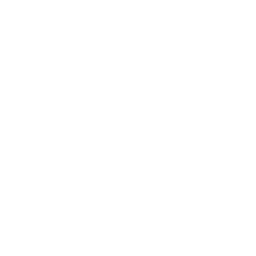

PROMPT: Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code

FINAL SVG:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100" height="100px" width="100%"><rect fill="black" x="0" y="0" width="100%" height="100%"/><circle cx="50" cy="50" r="40" fill="white" /><polygon points="70 70 70 80 60 80 50 70 40 80 50 70 60 80 70 80" fill="red" /></svg>

VALIDATION FINAL:
{'valid': True, 'reason': 'ok', 'length': 280, 'path_count': 0}
Has visible shape: True


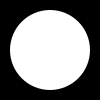

PROMPT: A blue circular icon with a white geometric pattern resembling a diamond or rhombus design.

FINAL SVG:
<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect width="256" height="256" fill="white"/></svg>

VALIDATION FINAL:
{'valid': True, 'reason': 'ok', 'length': 138, 'path_count': 0}
Has visible shape: True


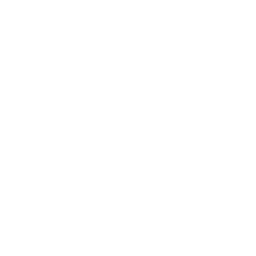

PROMPT: A single gray rectangular icon with a notched corner resembling a document or file icon is centered against a white background.

FINAL SVG:
<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect width="256" height="256" fill="white"/></svg>

VALIDATION FINAL:
{'valid': True, 'reason': 'ok', 'length': 138, 'path_count': 0}
Has visible shape: True


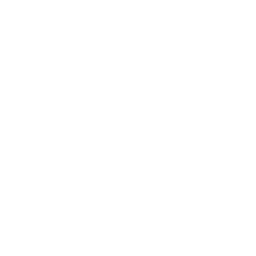

PROMPT: The image features a single black contour symbol resembling a stylized letter 'D' or a combination of geometric shapes, including an outer oval-like shape and an inner circular cutout, set against a pure white background.


KeyboardInterrupt: 

In [ ]:
from IPython.display import SVG, display

sample_prompts = short_df["prompt"].sample(10, random_state=42).tolist()

success = 0

for prompt in sample_prompts:
    print("=" * 100)
    print("PROMPT:", prompt)

    final_svg = generate_best_svg(prompt, model, tokenizer, tries=3)
    val = validate_svg(final_svg)

    print("\nFINAL SVG:")
    print(final_svg[:1200])
    print("\nVALIDATION FINAL:")
    print(val)
    print("Has visible shape:", has_visible_shape(final_svg))

    if val["valid"] and has_visible_shape(final_svg):
        success += 1

    try:
        display(SVG(final_svg))
    except Exception as e:
        print("Display failed:", e)

print(f"\nSuccessful non-empty SVGs: {success}/{len(sample_prompts)}")

Generate Submission file

In [17]:
import os
import pandas as pd

save_path = "/content/submission_partial.csv"

submission_rows = []

if os.path.exists(save_path):
    existing_df = pd.read_csv(save_path)
    submission_rows = existing_df.to_dict("records")
    done_ids = set(existing_df["id"])
    print(f"Resuming from {len(submission_rows)} samples")
else:
    done_ids = set()

tries = 1
max_new_tokens = 512

for i, row in test_df.iterrows():
    if row["id"] in done_ids:
        continue

    if i % 10 == 0:
        print(f"generating {i}/{len(test_df)}")

    pred_svg = generate_best_svg(
        prompt=row["prompt"],
        model=model,
        tokenizer=tokenizer,
        tries=tries,
        max_new_tokens=max_new_tokens
    )

    submission_rows.append({
        "id": row["id"],
        "svg": pred_svg
    })

    if len(submission_rows) % 10 == 0:
        pd.DataFrame(submission_rows).to_csv(save_path, index=False)
        print(f"Saved {len(submission_rows)} samples")

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("/content/submission.csv", index=False)

print("Done!")
print(submission_df.shape)

Resuming from 600 samples
generating 600/1000
Saved 610 samples
generating 610/1000
Saved 620 samples
generating 620/1000
Saved 630 samples
generating 630/1000
Saved 640 samples
generating 640/1000
Saved 650 samples
generating 650/1000
Saved 660 samples
generating 660/1000
Saved 670 samples
generating 670/1000
Saved 680 samples
generating 680/1000
Saved 690 samples
generating 690/1000
Saved 700 samples
generating 700/1000
Saved 710 samples
generating 710/1000
Saved 720 samples
generating 720/1000
Saved 730 samples
generating 730/1000
Saved 740 samples
generating 740/1000
Saved 750 samples
generating 750/1000
Saved 760 samples
generating 760/1000
Saved 770 samples
generating 770/1000
Saved 780 samples
generating 780/1000
Saved 790 samples
generating 790/1000
Saved 800 samples
generating 800/1000
Saved 810 samples
generating 810/1000
Saved 820 samples
generating 820/1000
Saved 830 samples
generating 830/1000
Saved 840 samples
generating 840/1000
Saved 850 samples
generating 850/1000
Save

Check output file

In [20]:
print(submission_df.shape)
print(submission_df.columns.tolist())
print(submission_df.isnull().sum())

(1000, 2)
['id', 'svg']
id     0
svg    0
dtype: int64
